## First Graph: Importing Relevant Classes

### Set the OpenAI API Key as an Environment Variable

In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

### Define the State

In [3]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [4]:
state = State(messages = [HumanMessage("Could you tell me a grook by Piet Hein?")])

In [5]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by Piet Hein?


### Define the Nodes

In [6]:
chat = ChatOpenAI(model = "gpt-4o", 
                  seed = 365, 
                  temperature = 0, 
                  max_completion_tokens = 100)

In [7]:
response = chat.invoke(state["messages"])

In [8]:
response.pretty_print()

================================== Ai Message ==================================

Certainly! Here is one of Piet Hein's well-known grooks:

**The Road to Wisdom**

The road to wisdom?—Well, it's plain
and simple to express:
Err
and err
and err again,
but less
and less
and less.

Piet Hein's grooks are known for their brevity and depth, often conveying profound insights with simplicity and wit.


In [9]:
def chatbot(state: State) -> State:

    print(f"\n-------> ENTERING chatbot:")
    
    response = chat.invoke(state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [10]:
chatbot(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

Certainly! Here's a well-known grook by Piet Hein:

```
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are known for their brevity and wit, often conveying deep insights in just a few lines.


{'messages': [AIMessage(content="Certainly! Here's a well-known grook by Piet Hein:\n\n```\nLosing One Glove\n\nLosing one glove\nis certainly painful,\nbut nothing\ncompared to the pain\nof losing one,\nthrowing away the other,\nand finding\nthe first one again.\n```\n\nPiet Hein's grooks are known for their brevity and wit, often conveying deep insights in just a few lines.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 18, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6084d5b3db', 'id': 'chatcmpl-DowekC8TYlxhwxKWrNKtItMBGBx7M', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019eade9-defb-7900-a274-2d8bf59eb654-0', usage_metadata={'input_tokens':

### Define the Graph

In [11]:
graph = StateGraph(State)

In [12]:
graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)


In [13]:
graph_compiled = graph.compile()

In [15]:
isinstance(graph, Runnable)

False

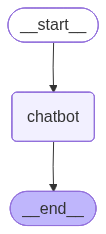

In [16]:
graph_compiled

### Test the Graph

In [18]:
graph_compiled.invoke(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

Certainly! Here is one of Piet Hein's well-known grooks:

**The Road to Wisdom**

The road to wisdom?—Well, it's plain
and simple to express:
Err
and err
and err again,
but less
and less
and less.

Piet Hein's grooks are known for their brevity and depth, often conveying profound truths in just a few lines.


{'messages': [AIMessage(content="Certainly! Here is one of Piet Hein's well-known grooks:\n\n**The Road to Wisdom**\n\nThe road to wisdom?—Well, it's plain\nand simple to express:\nErr\nand err\nand err again,\nbut less\nand less\nand less.\n\nPiet Hein's grooks are known for their brevity and depth, often conveying profound truths in just a few lines.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 18, 'total_tokens': 97, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6084d5b3db', 'id': 'chatcmpl-DowgjiSIGsqjT3H8xfHFlmzuSsAcE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019eadeb-be9c-7e72-846e-36c2f683fc62-0', usage_metadata={'input_tokens': 18, 'output_tokens': 79,

In [19]:
%mypy

Success: no issues found in 1 source file
Type checking successful
